In [3]:
# Step 1 — Load Data
import pandas as pd

import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, RESULTS_DIR, MODELS_DIR

df = pd.read_csv(
    PROCESSED_DATA_DIR / "feature_engineered_dataset.csv"
)

print(df.shape)

(100000, 21)


In [4]:
# Step 2 — Select Features

features = [
    'cpu_utilization',
    'memory_usage',
    'disk_io',
    'network_latency',
    'process_count',
    'thread_count',
    'context_switches',
    'cache_miss_rate',
    'temperature',
    'power_consumption',
    'uptime',
    'resource_stress_index',
    'cpu_memory_ratio',
    'disk_pressure',
    'context_switch_density',
    'cache_efficiency',
    'thermal_stress'
]

X = df[features]

y = df["status"]

In [5]:
# Step 3 — Standardize

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
# Model 1 — Z-Score

import numpy as np
from scipy.stats import zscore

z_scores = np.abs(
    zscore(X_scaled)
)

threshold = 3

z_predictions = (
    (z_scores > threshold)
    .any(axis=1)
).astype(int)

In [7]:
# Evaluate Z-Score

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print(
    "Precision:",
    precision_score(y, z_predictions)
)

print(
    "Recall:",
    recall_score(y, z_predictions)
)

print(
    "F1:",
    f1_score(y, z_predictions)
)

Precision: 0.0026425066062665155
Recall: 0.013861386138613862
F1: 0.004438807863031071


In [8]:
# Model 2 — Robust Z-Score

from scipy.stats import median_abs_deviation

median = np.median(
    X_scaled,
    axis=0
)

mad = median_abs_deviation(
    X_scaled,
    axis=0
)

robust_z = (
    0.6745 *
    (X_scaled - median)
    /
    mad
)

robust_predictions = (
    np.abs(robust_z) > 3.5
).any(axis=1).astype(int)

In [9]:
# Evaluate Robust Z

print(
    "Precision:",
    precision_score(y, robust_predictions)
)

print(
    "Recall:",
    recall_score(y, robust_predictions)
)

print(
    "F1:",
    f1_score(y, robust_predictions)
)

Precision: 0.007525964577793387
Recall: 0.1485148514851485
F1: 0.014325963421040065


In [10]:
# Confusion Matrix
# For both models:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y,
    z_predictions
)

print(cm)

[[93706  5284]
 [  996    14]]


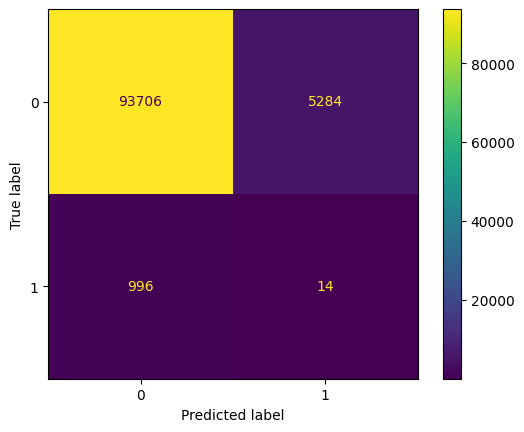

In [11]:
# Visualization
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y,
    z_predictions
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "zscore_confusion_matrix.png"
)

plt.show()

In [12]:
# Create Comparison Table

results = pd.DataFrame({

    "Model":[
        "Z-Score",
        "Robust Z-Score"
    ],

    "Precision":[
        precision_score(y,z_predictions),
        precision_score(y,robust_predictions)
    ],

    "Recall":[
        recall_score(y,z_predictions),
        recall_score(y,robust_predictions)
    ],

    "F1":[
        f1_score(y,z_predictions),
        f1_score(y,robust_predictions)
    ]
})

results

,Model,Precision,Recall,F1
0,Z-Score,0.002643,0.013861,0.004439
1,Robust Z-Score,0.007526,0.148515,0.014326


In [13]:
results.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False
)

In [14]:
# Model 3

# Step 4: Isolation Forest

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_model.fit(X_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [15]:
iso_predictions = iso_model.predict(X_scaled)

iso_predictions = [
    1 if x == -1 else 0
    for x in iso_predictions
]

In [16]:
# Step 5 — Evaluate Isolation Forest

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print(
    "Accuracy:",
    accuracy_score(y, iso_predictions)
)

print(
    "Precision:",
    precision_score(y, iso_predictions)
)

print(
    "Recall:",
    recall_score(y, iso_predictions)
)

print(
    "F1:",
    f1_score(y, iso_predictions)
)

Accuracy: 0.98016
Precision: 0.013
Recall: 0.01287128712871287
F1: 0.012935323383084577


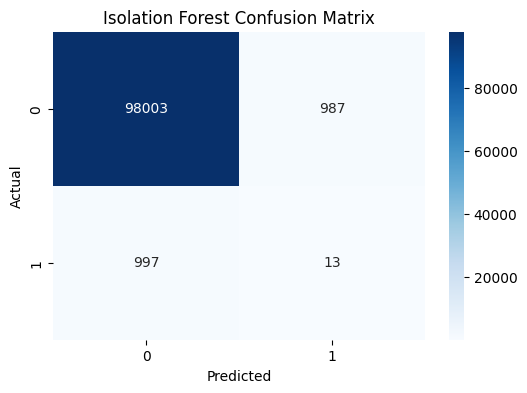

In [17]:
# Step 6 — Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y,
    iso_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Isolation Forest Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "isolation_forest_confusion_matrix.png",
    dpi=300
)

plt.show()

In [18]:
# Step 7 — Local Outlier Factor (LOF)
# Train

from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01
)

lof_predictions = lof_model.fit_predict(
    X_scaled
)

In [19]:
# Convert Output

lof_predictions = [
    1 if x == -1 else 0
    for x in lof_predictions
]

In [20]:
# Step 8 — Evaluate LOF

print(
    "Accuracy:",
    accuracy_score(y, lof_predictions)
)

print(
    "Precision:",
    precision_score(y, lof_predictions)
)

print(
    "Recall:",
    recall_score(y, lof_predictions)
)

print(
    "F1:",
    f1_score(y, lof_predictions)
)

Accuracy: 0.98006
Precision: 0.008
Recall: 0.007920792079207921
F1: 0.007960199004975124


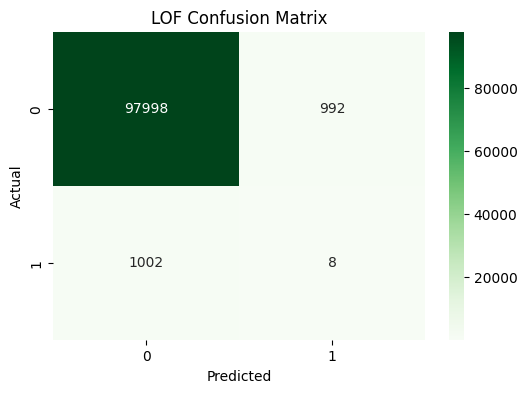

In [21]:
# Step 9 — LOF Confusion Matrix
cm = confusion_matrix(
    y,
    lof_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "LOF Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "lof_confusion_matrix.png",
    dpi=300
)

plt.show()

In [22]:
# Step 10 — ROC Curve

# For Isolation Forest:

from sklearn.metrics import roc_curve, auc

iso_scores = -iso_model.decision_function(
    X_scaled
)

fpr_iso, tpr_iso, _ = roc_curve(
    y,
    iso_scores
)

auc_iso = auc(
    fpr_iso,
    tpr_iso
)

In [23]:
# For LOF:

lof_scores = -lof_model.negative_outlier_factor_

fpr_lof, tpr_lof, _ = roc_curve(
    y,
    lof_scores
)

auc_lof = auc(
    fpr_lof,
    tpr_lof
)

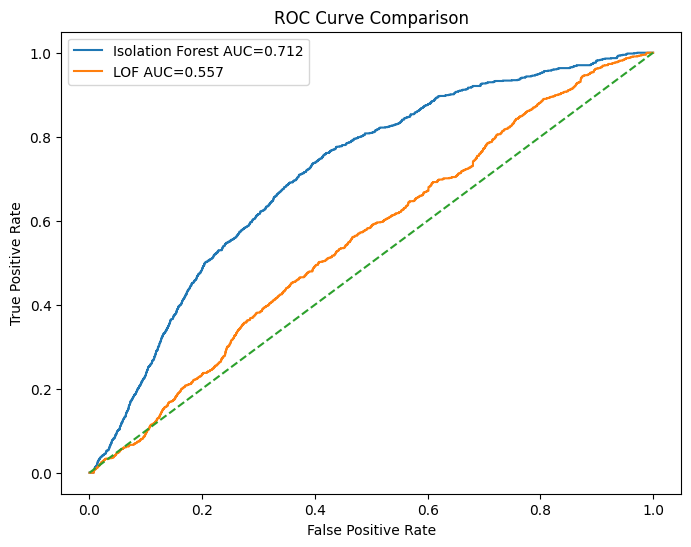

In [24]:
# Step 11 — Plot ROC
plt.figure(figsize=(8,6))

plt.plot(
    fpr_iso,
    tpr_iso,
    label=f'Isolation Forest AUC={auc_iso:.3f}'
)

plt.plot(
    fpr_lof,
    tpr_lof,
    label=f'LOF AUC={auc_lof:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "roc_curve_comparison.png",
    dpi=300
)

plt.show()

In [25]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Z-Score Metrics
z_precision = precision_score(y, z_predictions)
z_recall = recall_score(y, z_predictions)
z_f1 = f1_score(y, z_predictions)

# Robust Z-Score Metrics
robust_precision = precision_score(y, robust_predictions)
robust_recall = recall_score(y, robust_predictions)
robust_f1 = f1_score(y, robust_predictions)

# Isolation Forest Metrics
iso_precision = precision_score(y, iso_predictions)
iso_recall = recall_score(y, iso_predictions)
iso_f1 = f1_score(y, iso_predictions)

# LOF Metrics
lof_precision = precision_score(y, lof_predictions)
lof_recall = recall_score(y, lof_predictions)
lof_f1 = f1_score(y, lof_predictions)

In [26]:
# Step 12 — Create Model Comparison Table

comparison = pd.DataFrame({

    "Model":[
        "Z-Score",
        "Robust Z-Score",
        "Isolation Forest",
        "LOF"
    ],

    "Precision":[
        z_precision,
        robust_precision,
        precision_score(y, iso_predictions),
        precision_score(y, lof_predictions)
    ],

    "Recall":[
        z_recall,
        robust_recall,
        recall_score(y, iso_predictions),
        recall_score(y, lof_predictions)
    ],

    "F1":[
        z_f1,
        robust_f1,
        f1_score(y, iso_predictions),
        f1_score(y, lof_predictions)
    ]
})

comparison

,Model,Precision,Recall,F1
0,Z-Score,0.002643,0.013861,0.004439
1,Robust Z-Score,0.007526,0.148515,0.014326
2,Isolation Forest,0.013000,0.012871,0.012935
3,LOF,0.008000,0.007921,0.007960


In [27]:
# Save Results
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
comparison.to_csv(
    RESULTS_DIR / "anomaly_model_comparison.csv",
    index=False
)

In [28]:
IsolationForest(
    contamination=0.02,
    random_state=42
)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False


In [29]:
IsolationForest(
    contamination=0.05,
    random_state=42
)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False


In [30]:
df["risk_level"].value_counts(normalize=True) * 100

risk_level
Medium    66.258
Low       27.342
High       6.400
Name: proportion, dtype: float64

In [31]:
class_weight='balanced'

In [32]:
# Step 1 — Load Data (Risk Prediction)
# REFACTORED: Use config paths instead of hardcoded path

df = pd.read_csv(
    PROCESSED_DATA_DIR / "feature_engineered_dataset.csv"
)

In [33]:
from src.model_training import train_all_models

models = train_all_models(df)

rf_model = models["Random Forest"]
xgb_model = models["XGBoost"]

X_train = models["X_train"]
X_test = models["X_test"]

y_train = models["y_train"]
y_test = models["y_test"]

Model Saved: random_forest_model.pkl
Model Saved: xgboost_model.pkl


In [37]:
# Step 5 — Predict

rf_predictions = rf_model.predict(
    X_test
)

In [38]:
# Step 6 — Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average='weighted'
)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)

Accuracy: 0.99365
Precision: 0.993647734852107
Recall: 0.99365
F1: 0.9936486876558113


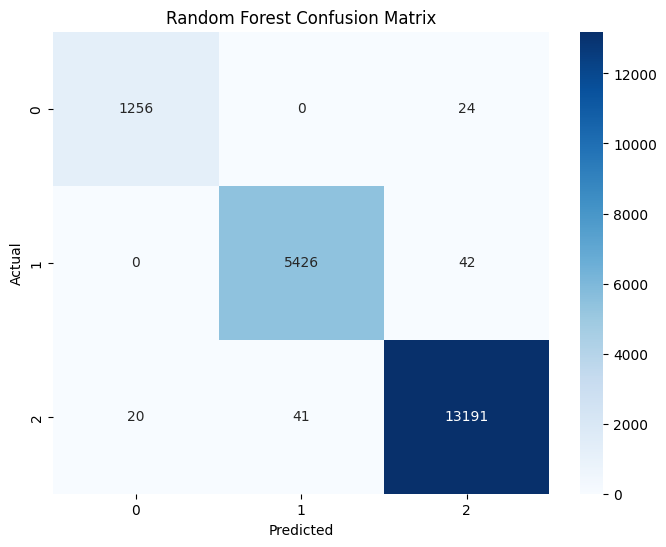

In [39]:
# Step 7 — Random Forest Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "rf_confusion_matrix.png",
    dpi=300
)

plt.show()

In [40]:
# Step 8 — Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

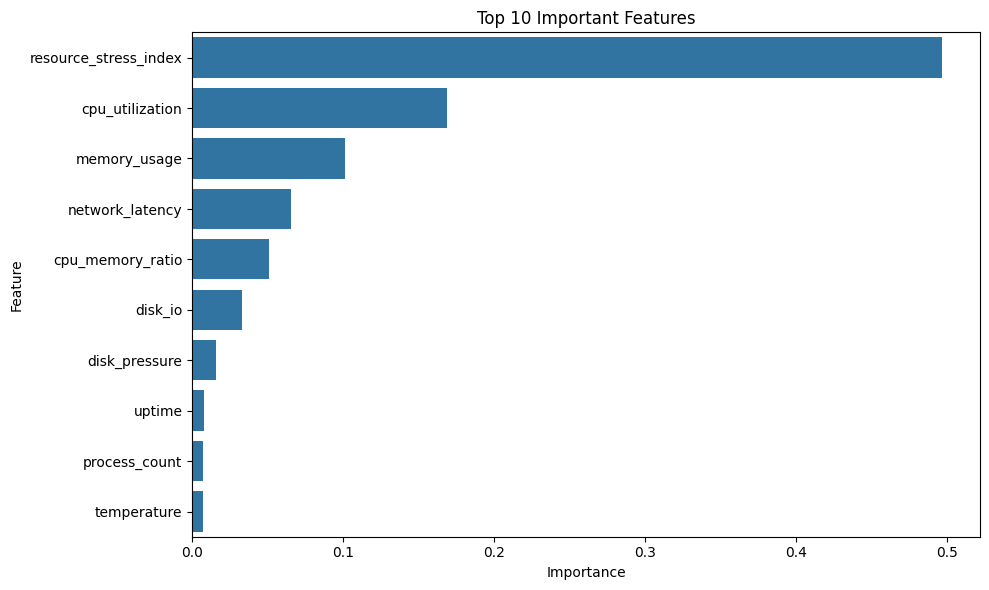

In [41]:
# Plot:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "feature_importance_rf.png",
    dpi=300
)

plt.show()

In [44]:
# Predict:

xgb_predictions = xgb_model.predict(
    X_test
)

In [45]:
# Metrics:

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions,
    average='weighted'
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average='weighted'
)

In [46]:
# Step 11 — Final Comparison Table

risk_results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision":[
        rf_precision,
        xgb_precision
    ],

    "Recall":[
        rf_recall,
        xgb_recall
    ],

    "F1":[
        rf_f1,
        xgb_f1
    ]
})

risk_results

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.99365,0.993648,0.99365,0.993649
1,XGBoost,0.99410,0.994101,0.99410,0.994100


In [47]:
# Save:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
risk_results.to_csv(
    RESULTS_DIR / "risk_prediction_results.csv",
    index=False
)

In [48]:
risk_results

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.99365,0.993648,0.99365,0.993649
1,XGBoost,0.99410,0.994101,0.99410,0.994100


In [49]:
importance.head(10)

,Feature,Importance
11,resource_stress_index,0.496878
0,cpu_utilization,0.168474
1,memory_usage,0.101294
3,network_latency,0.065326
12,cpu_memory_ratio,0.050871
2,disk_io,0.033184
13,disk_pressure,0.015821
10,uptime,0.007562
4,process_count,0.007234
8,temperature,0.007125
